# EDA Complète — Maintenance Prédictive Industrielle

**Tâche :** Prédiction de Panne dans les 24h (Classification Binaire)  
**Variable cible :** `failure_within_24h`  
**Dataset :** [Kaggle — Industrial Machine Predictive Maintenance](https://www.kaggle.com/datasets/tatheerabbas/industrial-machine-predictive-maintenance)  
**Dépôt Git :** [github.com/Vivien-Parsis/datascience-projet](https://github.com/Vivien-Parsis/datascience-projet)

---

## Table des matières

1. [Imports & Configuration](#1-imports--configuration)
2. [Chargement des données](#2-chargement-des-données)
3. [Fig.1 — Vue d'ensemble du dataset](#3-fig1--vue-densemble-du-dataset)
4. [Fig.2 — Distributions des capteurs par classe](#4-fig2--distributions-des-capteurs-par-classe)
5. [Fig.3 — Boxplots : capteurs vs cible](#5-fig3--boxplots--capteurs-vs-cible)
6. [Fig.4 — Matrice de corrélation](#6-fig4--matrice-de-corrélation)
7. [Fig.5 — Déséquilibre des classes](#7-fig5--déséquilibre-des-classes)
8. [Fig.6 — Relations entre capteurs clés](#8-fig6--relations-entre-capteurs-clés)
9. [Fig.7 — Analyse des outliers](#9-fig7--analyse-des-outliers)
10. [Synthèse EDA](#10-synthèse-eda)


## 1. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style="whitegrid", palette="Set2")
COLORS = {"no_fail": "#4C9BE8", "fail": "#E85D5D"}
TARGET = "failure_within_24h"
OUTPUT = "./figures/eda"
os.makedirs(OUTPUT, exist_ok=True)

print("Imports OK — dossier de sortie :", OUTPUT)


✅ Imports OK — dossier de sortie : ./figures/eda


## 2. Chargement des données

On charge le CSV et on définit les capteurs numériques utilisés dans l'EDA.

In [ ]:
df = pd.read_csv('./industrial_machine_maintenance.csv', parse_dates=['timestamp'])

NUMERIC_SENSORS = [
    'vibration_rms', 'temperature_motor', 'current_phase_avg',
    'pressure_level', 'rpm', 'hours_since_maintenance',
    'ambient_temp', 'rul_hours'
]

print(f"Shape : {df.shape}")
print(f"Période : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
df.head()


Shape : (24042, 15)
Période : 2024-01-01 → 2024-01-14


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [ ]:
# Aperçu des types et valeurs manquantes
print("\n--- Types de variables ---")
print(df.dtypes)
print("\n--- Valeurs manquantes ---")
print(df.isnull().sum())



--- Types de variables ---
timestamp                  datetime64[us]
machine_id                          int64
machine_type                          str
vibration_rms                     float64
temperature_motor                 float64
current_phase_avg                 float64
pressure_level                    float64
rpm                               float64
operating_mode                        str
hours_since_maintenance           float64
ambient_temp                      float64
rul_hours                         float64
failure_within_24h                  int64
failure_type                          str
estimated_repair_cost               int64
dtype: object

--- Valeurs manquantes ---
timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_

In [ ]:
# Statistiques descriptives
df.describe().round(2)


,timestamp,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042,24042.00,23042.00,23208.00,23311.00,23118.00,23509.00,24042.00,24042.00,24042.00,24042.00,24042.00
mean,2024-01-08 00:06:30.111721,10.51,1.62,51.40,8.82,59.01,1144.85,172.63,13.00,27.81,0.15,608.87
min,2024-01-01 00:00:00,1.00,0.35,28.00,2.20,10.10,124.10,0.00,8.00,0.50,0.00,0.00
25%,2024-01-04 12:24:13.750000,6.00,0.82,42.61,4.63,22.70,489.40,42.87,10.50,0.50,0.00,0.00
50%,2024-01-08 00:11:30,10.00,1.27,50.06,6.43,46.30,856.00,121.61,13.00,22.57,0.00,0.00
75%,2024-01-11 13:24:32.500000,15.00,2.27,59.96,13.12,94.70,1676.00,295.58,15.50,46.41,0.00,0.00
max,2024-01-14 23:59:38,20.00,10.00,95.00,35.00,206.50,4098.80,575.63,18.00,98.34,1.00,7995.00
std,NaN,5.75,1.08,12.52,5.37,38.72,912.67,150.72,2.88,26.39,0.36,1566.79


## 3. Fig.1 — Vue d'ensemble du dataset

Cette figure présente 6 vues synthétiques : répartition de la cible, valeurs manquantes, 
types de pannes, taux de panne par type de machine et par mode opératoire, 
et volume/taux par machine individuelle.

> **Observation clé :** 85,2 % des observations sont sans panne (classe 0) vs 14,8 % avec panne (classe 1) → déséquilibre ~5,75:1 à traiter.


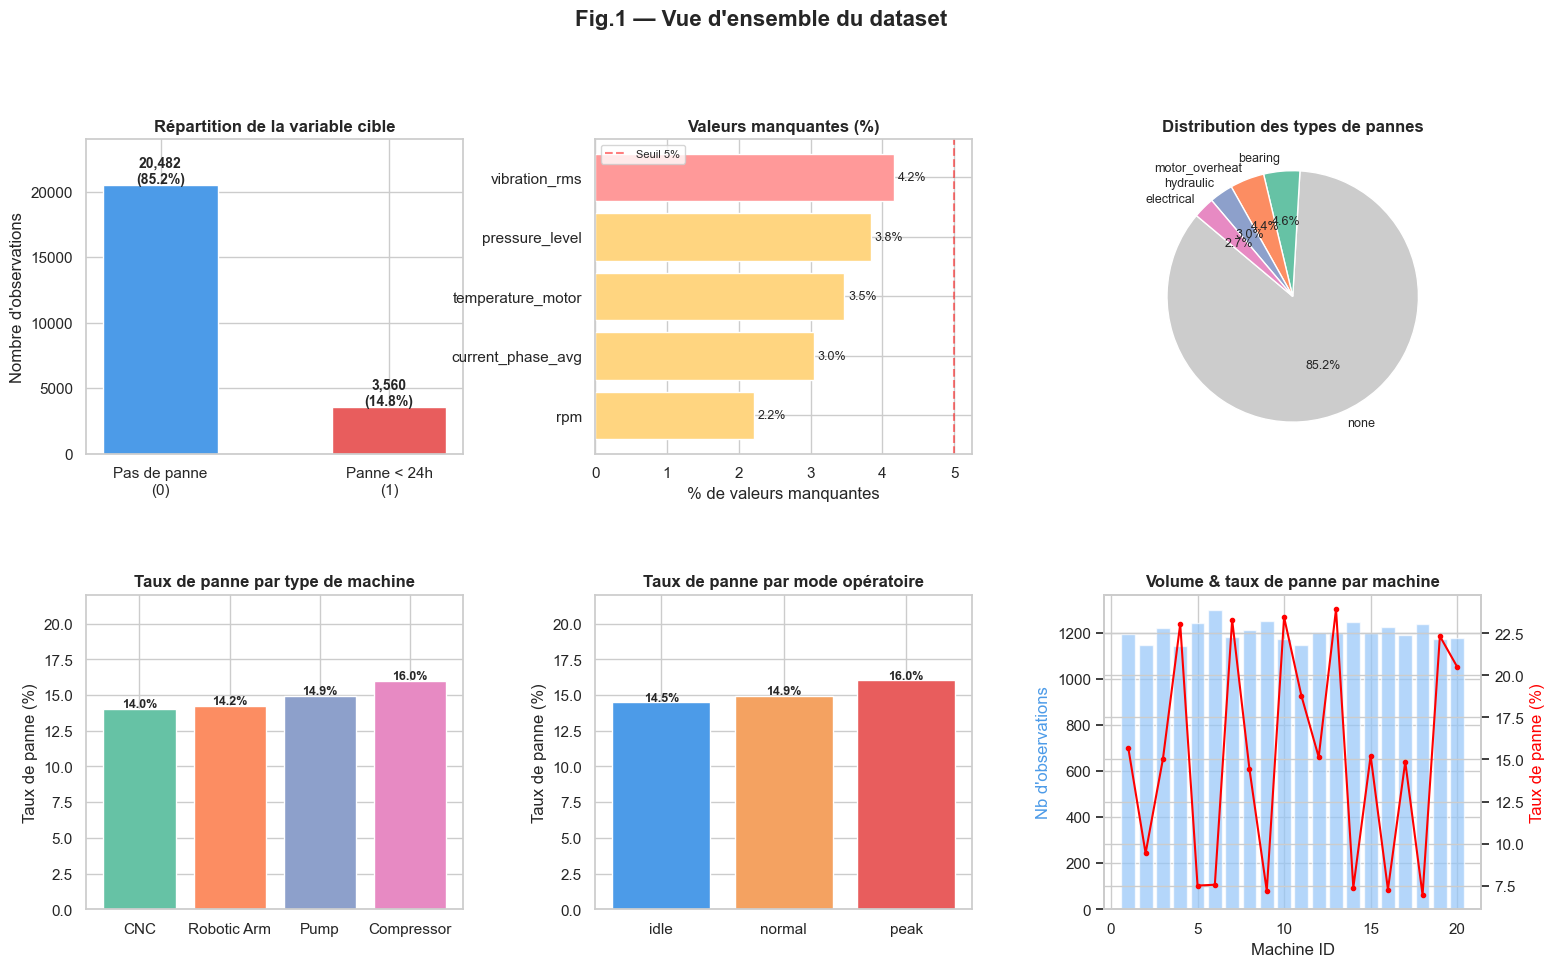

✅ Fig.1 sauvegardée


In [ ]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Fig.1 — Vue d'ensemble du dataset", fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1a — Répartition de la cible
ax1 = fig.add_subplot(gs[0, 0])
counts = df[TARGET].value_counts()
bars = ax1.bar(
    ['Pas de panne\n(0)', 'Panne < 24h\n(1)'],
    counts.values,
    color=[COLORS['no_fail'], COLORS['fail']], edgecolor='white', width=0.5
)
for bar, val in zip(bars, counts.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
        f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold'
    )
ax1.set_title("Répartition de la variable cible", fontweight='bold')
ax1.set_ylabel("Nombre d'observations")
ax1.set_ylim(0, 24000)

# 1b — Valeurs manquantes
ax2 = fig.add_subplot(gs[0, 1])
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing = missing[missing > 0]
colors_m = ['#FF9999' if v > 4 else '#FFD580' for v in missing.values]
bars2 = ax2.barh(missing.index, missing.values, color=colors_m, edgecolor='white')
for bar, val in zip(bars2, missing.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax2.set_title("Valeurs manquantes (%)", fontweight='bold')
ax2.set_xlabel("% de valeurs manquantes")
ax2.axvline(5, color='red', linestyle='--', alpha=0.5, label='Seuil 5%')
ax2.legend(fontsize=8)

# 1c — Types de pannes
ax3 = fig.add_subplot(gs[0, 2])
failure_counts = df['failure_type'].value_counts()
palette = ['#cccccc'] + list(sns.color_palette("Set2", len(failure_counts)-1))
ax3.pie(failure_counts.values, labels=failure_counts.index,
        colors=palette, autopct='%1.1f%%', startangle=140,
        textprops={'fontsize': 9})
ax3.set_title("Distribution des types de pannes", fontweight='bold')

# 1d — Taux de panne par type de machine
ax4 = fig.add_subplot(gs[1, 0])
fail_by_type = df.groupby('machine_type')[TARGET].mean().sort_values() * 100
bars4 = ax4.bar(fail_by_type.index, fail_by_type.values,
                color=sns.color_palette("Set2", len(fail_by_type)), edgecolor='white')
for bar, val in zip(bars4, fail_by_type.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax4.set_title("Taux de panne par type de machine", fontweight='bold')
ax4.set_ylabel("Taux de panne (%)")
ax4.set_ylim(0, 22)

# 1e — Taux de panne par mode opératoire
ax5 = fig.add_subplot(gs[1, 1])
fail_by_mode = df.groupby('operating_mode')[TARGET].mean().sort_values() * 100
bars5 = ax5.bar(fail_by_mode.index, fail_by_mode.values,
                color=['#4C9BE8', '#F4A261', '#E85D5D'], edgecolor='white')
for bar, val in zip(bars5, fail_by_mode.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax5.set_title("Taux de panne par mode opératoire", fontweight='bold')
ax5.set_ylabel("Taux de panne (%)")
ax5.set_ylim(0, 22)

# 1f — Volume & taux par machine
ax6 = fig.add_subplot(gs[1, 2])
machine_counts = df.groupby('machine_id')[TARGET].agg(['count', 'sum'])
machine_counts['fail_rate'] = machine_counts['sum'] / machine_counts['count'] * 100
ax6.bar(machine_counts.index, machine_counts['count'], color='#94C5F8', label='Total', alpha=0.7)
ax6_twin = ax6.twinx()
ax6_twin.plot(machine_counts.index, machine_counts['fail_rate'], 'r.-', label='Taux panne', linewidth=1.5)
ax6.set_title("Volume & taux de panne par machine", fontweight='bold')
ax6.set_xlabel("Machine ID")
ax6.set_ylabel("Nb d'observations", color='#4C9BE8')
ax6_twin.set_ylabel("Taux de panne (%)", color='red')

plt.savefig(f"{OUTPUT}/fig1_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig.1 sauvegardée")


## 4. Fig.2 — Distributions des capteurs par classe

Histogrammes superposés (classe 0 en bleu, classe 1 en rouge) avec lignes de moyenne.

> **Observation clé :** `temperature_motor` et `vibration_rms` montrent les distributions les plus séparées entre les deux classes — ce sont les capteurs les plus discriminants.


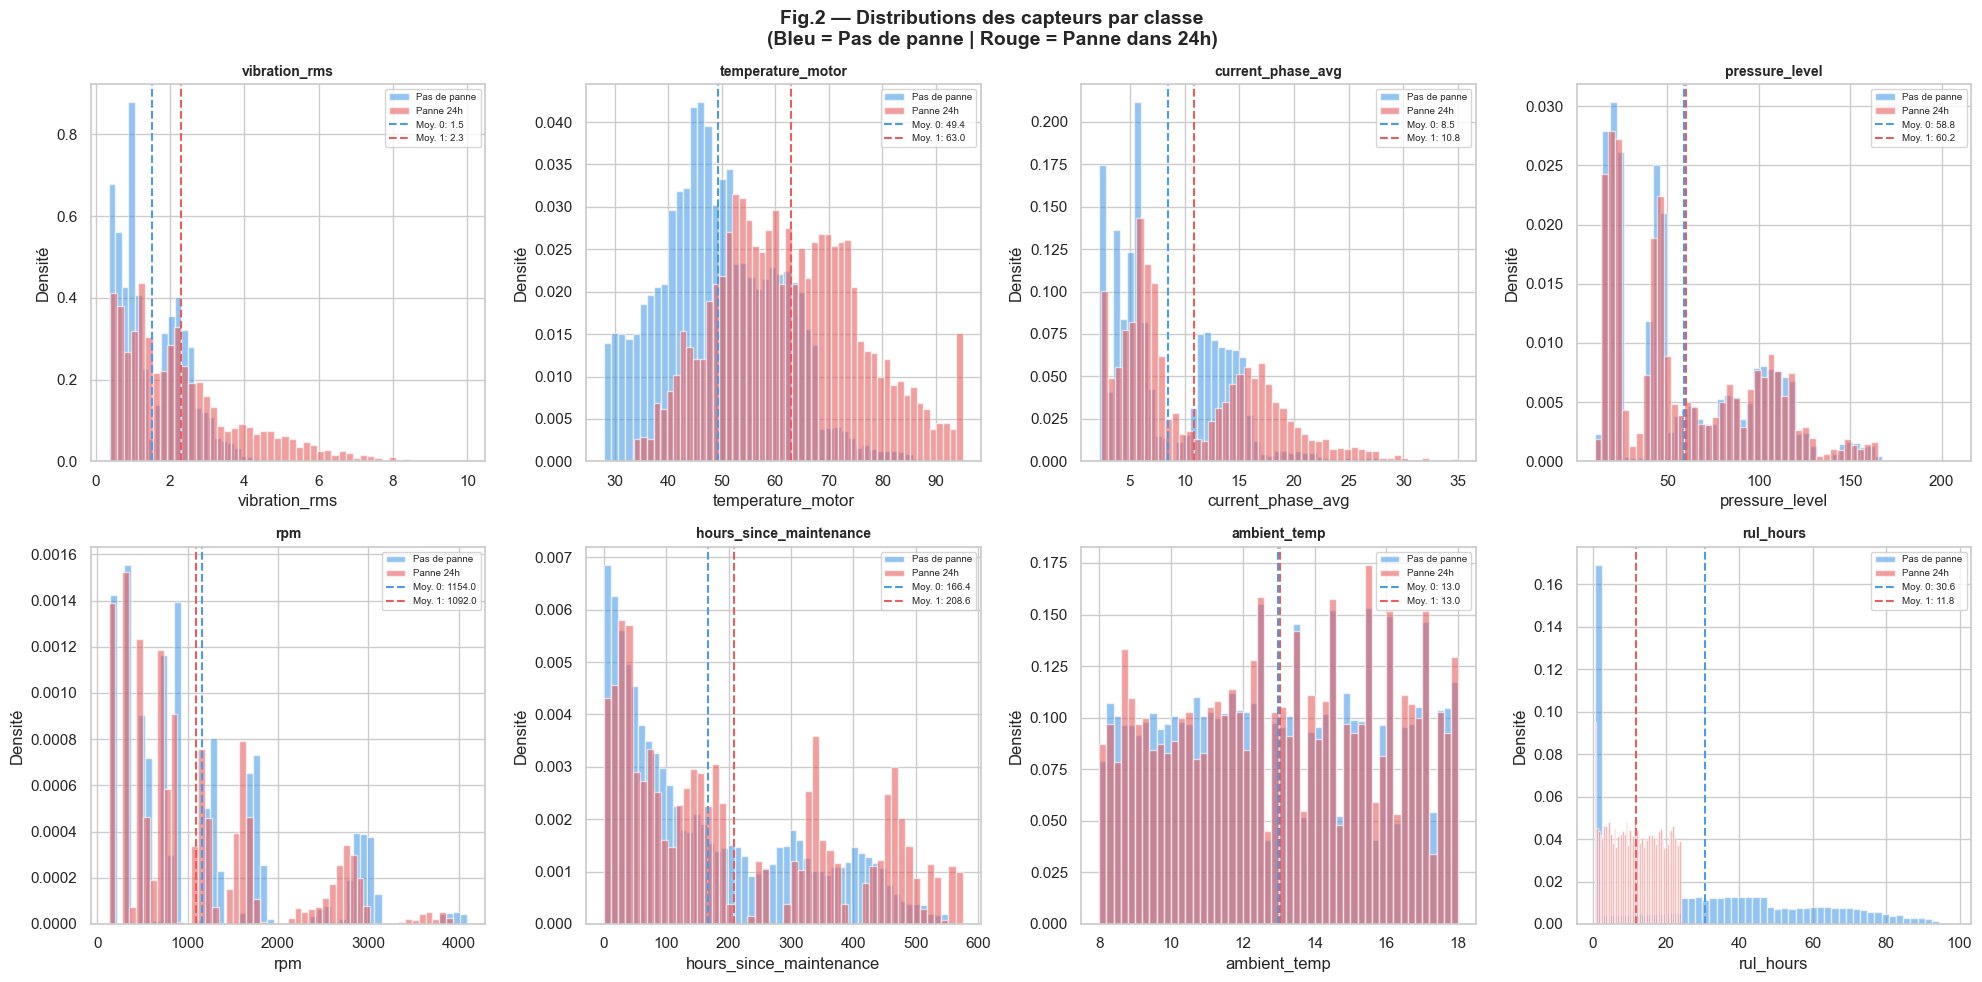

Fig.2 sauvegardée


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    "Fig.2 — Distributions des capteurs par classe\n(Bleu = Pas de panne | Rouge = Panne dans 24h)",
    fontsize=14, fontweight='bold'
)

for ax, col in zip(axes.flatten(), NUMERIC_SENSORS):
    df0 = df[df[TARGET]==0][col].dropna()
    df1 = df[df[TARGET]==1][col].dropna()

    ax.hist(df0, bins=50, alpha=0.6, color=COLORS['no_fail'], density=True, label='Pas de panne')
    ax.hist(df1, bins=50, alpha=0.6, color=COLORS['fail'],    density=True, label='Panne 24h')

    ax.axvline(df0.mean(), color=COLORS['no_fail'], linestyle='--', linewidth=1.5,
               label=f'Moy. 0: {df0.mean():.1f}')
    ax.axvline(df1.mean(), color=COLORS['fail'],    linestyle='--', linewidth=1.5,
               label=f'Moy. 1: {df1.mean():.1f}')

    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.legend(fontsize=7)
    ax.set_ylabel("Densité")

plt.tight_layout()
plt.savefig(f"{OUTPUT}/fig2_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig.2 sauvegardée")


## 5. Fig.3 — Boxplots : capteurs vs cible

Boxplots en entailles (notched) permettant de comparer les médianes entre classes.

> **Observation clé :** Les médianes de `temperature_motor` et `rul_hours` sont nettement différentes entre les deux classes. L'absence de chevauchement des entailles confirme une différence statistiquement significative.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Fig.3 — Boxplots : signaux capteurs vs variable cible",
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), NUMERIC_SENSORS):
    data_plot = [df[df[TARGET]==0][col].dropna(), df[df[TARGET]==1][col].dropna()]
    bp = ax.boxplot(data_plot, labels=['Pas de panne', 'Panne 24h'],
                    patch_artist=True, notch=True, showfliers=False)
    bp['boxes'][0].set_facecolor(COLORS['no_fail']); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(COLORS['fail']);    bp['boxes'][1].set_alpha(0.7)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/fig3_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig.3 sauvegardée")


## 6. Fig.4 — Matrice de corrélation

Deux vues : heatmap complète (triangle inférieur) et corrélations avec la variable cible triées.

> **Observation clé :** `temperature_motor` (+0,386) et `vibration_rms` (+0,264) sont les features les plus corrélées à la cible. `rul_hours` présente une corrélation négative forte (−0,253) : plus la durée de vie restante est faible, plus le risque est élevé.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Fig.4 — Analyse des corrélations", fontsize=14, fontweight='bold')

# Heatmap complète
corr_cols = NUMERIC_SENSORS + [TARGET]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.5, annot_kws={'fontsize': 8})
axes[0].set_title("Matrice de corrélation complète", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Corrélations avec la cible
corr_target = df[corr_cols].corr()[TARGET].drop(TARGET).sort_values()
colors_corr = [COLORS['fail'] if v > 0 else COLORS['no_fail'] for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors_corr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, (idx, val) in enumerate(corr_target.items()):
    axes[1].text(
        val + (0.005 if val >= 0 else -0.005), i,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )
axes[1].set_title(f"Corrélations avec {TARGET}", fontweight='bold')
axes[1].set_xlabel("Coefficient de corrélation de Pearson")

plt.tight_layout()
plt.savefig(f"{OUTPUT}/fig4_correlations.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig.4 sauvegardée")


## 7. Fig.5 — Déséquilibre des classes & analyse

Trois vues : répartition en camembert, taux de panne croisé machine × mode, évolution temporelle.

> **Observation clé :** Le taux de panne est légèrement plus élevé en mode `peak` et pour les `Compressor`. L'évolution mensuelle montre une stabilité du taux global (~14,8 %), sans saisonnalité marquée.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Fig.5 — Déséquilibre des classes & analyse", fontsize=14, fontweight='bold')

# 5a — Camembert
ax = axes[0]
ratio = df[TARGET].value_counts()
ax.pie(ratio.values,
       labels=['Pas de panne (85,2 %)', 'Panne 24h (14,8 %)'],
       colors=[COLORS['no_fail'], COLORS['fail']],
       autopct='%1.1f%%', startangle=90,
       explode=(0, 0.05), shadow=True)
ax.set_title(f"Déséquilibre : ratio {ratio[0]//ratio[1]}:1\n→ Nécessite une stratégie adaptée",
             fontweight='bold')

# 5b — Heatmap machine × mode
ax = axes[1]
pivot = df.pivot_table(values=TARGET, index='machine_type',
                       columns='operating_mode', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Taux de panne (%)'})
ax.set_title("Taux de panne (%) :\ntype machine × mode opératoire", fontweight='bold')

# 5c — Évolution temporelle
ax = axes[2]
df['month'] = df['timestamp'].dt.to_period('M')
monthly = df.groupby('month')[TARGET].mean() * 100
monthly.index = monthly.index.astype(str)
ax.plot(range(len(monthly)), monthly.values, 'o-', color=COLORS['fail'],
        linewidth=2, markersize=5)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color=COLORS['fail'])
ax.axhline(monthly.mean(), color='gray', linestyle='--',
           label=f'Moy. globale : {monthly.mean():.1f} %')
ax.set_title("Évolution mensuelle du taux de panne", fontweight='bold')
ax.set_xlabel("Mois")
ax.set_ylabel("Taux de panne (%)")
ax.set_xticks(range(0, len(monthly), 2))
ax.set_xticklabels([monthly.index[i] for i in range(0, len(monthly), 2)],
                   rotation=45, fontsize=8)
ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT}/fig5_imbalance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig.5 sauvegardée")


## 8. Fig.6 — Relations entre capteurs clés

Nuages de points colorés par classe pour 3 paires de capteurs stratégiques.

> **Observation clé :** Les points rouges (panne) se concentrent dans les zones haute température + haute vibration, et faible `rul_hours`. Cela confirme que ces capteurs capturent un signal de dégradation progressive.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Fig.6 — Relations entre capteurs clés (coloré par cible)",
             fontsize=14, fontweight='bold')

pairs = [
    ('vibration_rms',   'temperature_motor'),
    ('rul_hours',       'temperature_motor'),
    ('vibration_rms',   'rul_hours')
]

for ax, (x_col, y_col) in zip(axes, pairs):
    df_sample = df.dropna(subset=[x_col, y_col]).sample(min(3000, len(df)), random_state=42)
    df0 = df_sample[df_sample[TARGET]==0]
    df1 = df_sample[df_sample[TARGET]==1]
    ax.scatter(df0[x_col], df0[y_col], alpha=0.3, s=10,
               color=COLORS['no_fail'], label='Pas de panne')
    ax.scatter(df1[x_col], df1[y_col], alpha=0.5, s=15,
               color=COLORS['fail'], label='Panne 24h')
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.set_title(f"{x_col}\nvs {y_col}", fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/fig6_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig.6 sauvegardée")


## 9. Fig.7 — Analyse des outliers (méthode IQR)

Pour chaque capteur : distribution des valeurs normales (bleu) vs outliers IQR (rouge) avec les bornes basse/haute.

> **Observation clé :** Les outliers de `vibration_rms` (2,0 %) et `rpm` (1,6 %) correspondent probablement à de vraies anomalies pré-panne. **Ne pas les supprimer** sans vérification — ils peuvent être porteurs d'information prédictive.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Fig.7 — Détection et analyse des outliers (méthode IQR)",
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), NUMERIC_SENSORS):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers_mask = (data < low) | (data > high)
    n_out = outliers_mask.sum()

    ax.hist(data[~outliers_mask], bins=40, alpha=0.7, color='#94C5F8', label='Normal')
    if n_out > 0:
        ax.hist(data[outliers_mask], bins=20, alpha=0.8, color='#FF9999',
                label=f'Outliers ({n_out})')
    ax.axvline(low,  color='orange', linestyle='--', linewidth=1, label='Borne basse')
    ax.axvline(high, color='red',    linestyle='--', linewidth=1, label='Borne haute')
    ax.set_title(f"{col}\n{n_out} outliers ({n_out/len(df)*100:.1f}%)",
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/fig7_outliers.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig.7 sauvegardée")


## 10. Synthèse EDA

Récapitulatif structuré des points clés et recommandations pour la suite du pipeline.


In [ ]:
# Calcul des statistiques de synthèse
n_total    = len(df)
n_fail     = int(df[TARGET].sum())
n_safe     = n_total - n_fail
ratio      = n_safe // n_fail
miss_pct   = (df.isnull().sum() / n_total * 100).sort_values(ascending=False)
miss_pct   = miss_pct[miss_pct > 0]
corr_cible = df[NUMERIC_SENSORS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

sep = "=" * 60
print(sep)
print("SYNTHÈSE EDA — Points clés")
print(sep)

print("\nDATASET")
print(f"  - {n_total:,} observations | {df.shape[1]} variables")
print(f"  - Période : {df['timestamp'].min().date()} -> {df['timestamp'].max().date()}")
print(f"  - {df['machine_id'].nunique()} machines | {df['machine_type'].nunique()} types")
print(f"    ({', '.join(df['machine_type'].unique())})")

pct0 = round(n_safe / n_total * 100, 1)
pct1 = round(n_fail / n_total * 100, 1)
print(f"\nVARIABLE CIBLE : {TARGET}")
print(f"  - Classe 0 (pas de panne) : {n_safe:,}  ({pct0}%)")
print(f"  - Classe 1 (panne < 24h)  : {n_fail:,}   ({pct1}%)")
print(f"  - Ratio déséquilibre      : ~{ratio}:1  →  TRAITEMENT REQUIS")

print("\nVALEURS MANQUANTES")
for col, pct in miss_pct.items():
    print(f"  - {col:<25} : {pct:.1f}%")
print("  → Imputation recommandée : médiane par machine_type")

print("\nTOP CORRÉLATIONS AVEC LA CIBLE")
for col, val in corr_cible.items():
    flag = "[**]" if abs(val) > 0.2 else "    "
    print(f"  {flag} {col:<25} : {val:+.3f}")

print("\nOUTLIERS NOTABLES")
print("  - vibration_rms : ~2.0%  -> probables anomalies pre-panne (ne pas supprimer)")
print("  - rpm           : ~1.6%  -> idem")

print("\nRECOMMANDATIONS POUR LA SUITE")
recs = [
    "Imputer les NaN (mediane par machine_type via sklearn Pipeline)",
    "Gerer le desequilibre : class_weight='balanced' + SMOTE",
    "Encoder : machine_type, operating_mode (OneHotEncoder)",
    "Supprimer : timestamp, machine_id, failure_type, estimated_repair_cost (data leakage)",
    "Surveiller rul_hours (forte correlation -> potentiel proxy de la cible)",
    "Normaliser pour LR et MLP, pas necessaire pour RF/XGB",
]
for i, r in enumerate(recs, 1):
    print(f"{i} . {r}")
